In [76]:
# Imports
from config import *

import cobaya
import cobaya.samplers.mcmc
import getdist.plots as gdplt
%matplotlib inline

# import cobaya, yaml, getdist

# Before running the chains

In [64]:
# Check to see if you can import the likelihoods

from Models import TargetData, MapData, HaloModels, FFTs, Projections, Profiles, SHMRs, HODs, Dust, Measurements, Plots, Studies, Spectra2
import Models.Studies as Studies
import Models.HODs as HODs
import Models.HaloModels as HaloModels
import SOLikelihoods

### Run Model and put in guesses

In [65]:
# Reload every modules to updates
importlib.reload(SOLikelihoods); importlib.reload(Projections); importlib.reload(HaloModels); importlib.reload(TargetData); importlib.reload(MapData); importlib.reload(Profiles); importlib.reload(Measurements); importlib.reload(Studies); importlib.reload(Spectra2); importlib.reload(HODs)

# Define YAML file and print steps
SOLikelihoods.YAML_FILE  = f"{CAPPIBARAS_PATH}/yamls/runchains_final.yaml"
SOLikelihoods.VERBOSE = True
yamlinfo = cobaya.yaml.yaml_load_file(SOLikelihoods.YAML_FILE).copy()

likelis = cobaya.get_model(SOLikelihoods.YAML_FILE).likelihood

[model] *WARNING* Ignored blocks/options: ['shared', 'output']


Loading in Fixed Parameters and Data/Model Dictionaries from yaml file
Loading and Initializing Halo Model: pyccl_model {'MassDef': '200c', 'MassFunc': 'Tinker08', 'HaloBias': 'Tinker10', 'PowSpec': 'Linear', 'Concentration': 'Bhattacharya13'}
Loading in Measurement Data: RiedGuachalla2025 {'bin': 'all'}
Loading in Map Data: Coulton2024 {}
Loading in Target Data: RiedGuachalla2025 {'bin': 'all'}
Making Redshift and Halo Mass Distributions:
Setting up Projection, Beam Convolution, Aperture methods: Popik2025 {}
Setting up Profile Model Popik2026 {}
Setting up Basic Average
Setting up HOD Average
HOD Model: logMhMean=13.00
Setting up Data
Setting up Profile Model
1.00e-03 Mpc<r<1.38e+02 Mpc, N_r=50


In [90]:
parsref = {}
for k, v in yamlinfo['params'].items():
    if isinstance(v, dict) and "ref" in v:
        if isinstance(v['ref'], dict) and "loc" in v['ref']:
            parsref[k] = v['ref']['loc']
        else:
            parsref[k] = v['ref']
            
            
parsref['xc_k'] = 1.5 # -0.2

defaults, guesses = {}, {}
for likeli in likelis.values():
    defaults[likeli.get_name()] = {
        'chi2overN': -2*likeli.logp()/len(likeli.data.x),
        'tot': likeli.model(),
        '1h': likeli.project(likeli.avemeth(likeli.prof1h())),
        '2h': likeli.project(likeli.avemeth(likeli.prof2h())),
        'proftot': likeli.avemeth(likeli.prof()),
        'prof1h': likeli.avemeth(likeli.prof1h()),
        'prof2h': likeli.avemeth(likeli.prof2h())
    }
    
    guesses[likeli.get_name()] = {
        'chi2overN': -2*likeli.logp(**parsref)/len(likeli.data.x),
        'tot': likeli.model(parsref),
        '1h': likeli.project(likeli.avemeth(likeli.prof1h(parsref))),
        '2h': likeli.project(likeli.avemeth(likeli.prof2h(parsref))),
        'proftot': likeli.avemeth(likeli.prof(parsref)),
        'prof1h': likeli.avemeth(likeli.prof1h(parsref)),
        'prof2h': likeli.avemeth(likeli.prof2h(parsref))
    }

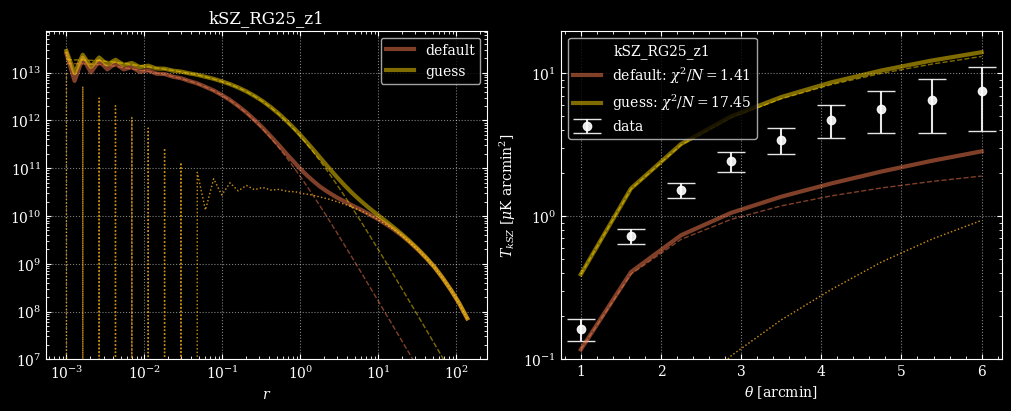

In [91]:
nrows = len(likelis)
fig, axs = plt.subplots(nrows, 2, figsize=(10, 4*nrows), layout='constrained')
if nrows == 1:
    axs = axs[None, :]

for (axprof, axdata), likeli in zip(axs, likelis.values()):
    name = likeli.get_name()

    # Left: 1h/2h/total profile (pre-projection) vs r
    for vers, label, color in zip([defaults[name], guesses[name]], ['default', 'guess'], ['coral', 'gold']):
        axprof.plot(likeli.r, vers['prof1h'], ls='--', lw=1, c=color, alpha=0.5)
        axprof.plot(likeli.r, vers['prof2h'], ls=':', lw=1, c=color, alpha=0.5)
        axprof.plot(likeli.r, vers['proftot'], lw=3, label=label, c=color, alpha=0.5)
    axprof.set(xscale='log', yscale='log', ylim=(1e7, None), xlabel=r'$r$', title=name)
    axprof.legend()

    # Right: data and projected SZ signal
    axdata.errorbar(likeli.data.x, likeli.data.y, np.diag(likeli.data.cov)**0.5, label='data', c='white', marker='o', capsize=10, ls='None', alpha=0.9)

    for vers, label, color in zip([defaults[name], guesses[name]], ['default', 'guess'], ['coral', 'gold']):
        # Plot 1h and 2h components
        axdata.plot(likeli.data.x, vers['1h'], ls='--', lw=1, c=color, alpha=0.5)
        axdata.plot(likeli.data.x, vers['2h'], ls=':', lw=1, c=color, alpha=0.5)
        # Plot total model
        axdata.plot(likeli.data.x, vers['tot'], lw=3, label=rf"{label}: $\chi^2/N=${vers['chi2overN']:.2f}", c=color, alpha=0.5)

    axdata.legend(title=name)
    if "kSZ" in name:
        axdata.set(yscale='log', ylim=(1e-1, None), ylabel=r'$T_{kSZ} \ [\mu \text{K} \ \text{arcmin}^2]$', xlabel=r'$\theta$ [arcmin]')
    elif "tSZ" in name:
        axdata.set(ylim=(-0.5e-6, 6e-6), ylabel=r'$y$', xlabel=r'$\theta$ [arcmin]')

plt.show()

### Do a quick minimizer run

In [28]:
importlib.reload(SOLikelihoods)


SOLikelihoods.YAML_FILE = f"{CAPPIBARAS_PATH}/yamls/runchains_final.yaml"
SOLikelihoods.VERBOSE = False

# Run a quick minimizer but change the output file so it doesn't overwrite the real one
yamlinfo_min = cobaya.yaml.yaml_load_file(SOLikelihoods.YAML_FILE).copy()

yamlinfo_min["output"] = f"{OUTPUT_PATH}/minimizer_runs/runchainstest1"
yamlinfo_min["sampler"] = {"minimize": {'ignore_prior': True, 'best_of': 2}}

updated_info_minimizer, minimizer = cobaya.run(yamlinfo_min, force=True)

INFO:output:Output to be read-from/written-into folder '/pscratch/sd/c/cpopik/CAPPIBARAS/runs/minimizer_runs', with prefix 'runchainstest1'


[output] Output to be read-from/written-into folder '/pscratch/sd/c/cpopik/CAPPIBARAS/runs/minimizer_runs', with prefix 'runchainstest1'


INFO:minimize:Initializing


HOD Model: logMhMean=13.00
1.00e-03 Mpc<r<1.38e+02 Mpc, N_r=50
[minimize] Initializing


INFO:minimize:Run 1/2 will start from random initial point:


...

[minimize] -log(likelihood) minimized to -2.71157


INFO:minimize:Parameter values at minimum:
   weight  minuslogpost  logrho0    beta_k   alpha_k      xc_k       gamma_k  logrho0_2h  beta_k_2h  alpha_k_2h  xc_k_2h  gamma_k_2h  minuslogprior  minuslogprior__0      chi2  chi2__kSZ_RG25_z1
0     1.0     17.085355  2.19868  2.182602  3.161155  0.734316 -5.551115e-17    2.039652   2.935888    1.668489  0.61108   -0.745432      19.796925         19.796925 -5.423139          -5.423139


[minimize] Parameter values at minimum:
   weight  minuslogpost  logrho0    beta_k   alpha_k      xc_k       gamma_k  logrho0_2h  beta_k_2h  alpha_k_2h  xc_k_2h  gamma_k_2h  minuslogprior  minuslogprior__0      chi2  chi2__kSZ_RG25_z1
0     1.0     17.085355  2.19868  2.182602  3.161155  0.734316 -5.551115e-17    2.039652   2.935888    1.668489  0.61108   -0.745432      19.796925         19.796925 -5.423139          -5.423139


INFO:minimize:Full set of minima:
{'0': (-2.11943833217868, True), '1': (-2.7115694280937532, True)}


[minimize] Full set of minima:
{'0': (-2.11943833217868, True), '1': (-2.7115694280937532, True)}


In [68]:
parsfit = {k: minimizer.products()["minimum"][k] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}

minimizerfits = {}
for likeli in likelis.values():
    minimizerfits[likeli.get_name()] = {
        'chi2overN': -2*likeli.logp(**parsfit)/len(likeli.data.x),
        'tot': likeli.model(parsfit),
        '1h': likeli.project(likeli.avemeth(likeli.prof1h(parsfit))),
        '2h': likeli.project(likeli.avemeth(likeli.prof2h(parsfit))),
        'proftot': likeli.avemeth(likeli.prof(parsfit)),
        'prof1h': likeli.avemeth(likeli.prof1h(parsfit)),
        'prof2h': likeli.avemeth(likeli.prof2h(parsfit))
    }

In [ ]:
nrows = len(likelis)
fig, axs = plt.subplots(nrows, 2, figsize=(10, 4*nrows), layout='constrained')
if nrows == 1:
    axs = axs[None, :]

versions = [(defaults, 'default', 'coral'), (guesses, 'guess', 'gold'), (minimizerfits, 'minimized', 'mediumseagreen')]

for (axprof, axdata), likeli in zip(axs, likelis.values()):
    name = likeli.get_name()

    # Left: 1h/2h/total profile (pre-projection) vs r
    for versdict, label, color in versions:
        vers = versdict[name]
        axprof.plot(likeli.r, vers['prof1h'], ls='--', lw=1, c=color, alpha=0.5)
        axprof.plot(likeli.r, vers['prof2h'], ls=':', lw=1, c=color, alpha=0.5)
        axprof.plot(likeli.r, vers['proftot'], lw=3, label=label, c=color, alpha=0.5)
    axprof.set(xscale='log', yscale='log', ylim=(1e7, None), xlabel=r'$r$', title=name)
    axprof.legend()

    # Right: data and projected SZ signal
    axdata.errorbar(likeli.data.x, likeli.data.y, np.diag(likeli.data.cov)**0.5, label='data', c='white', marker='o', capsize=10, ls='None', alpha=0.9)

    for versdict, label, color in versions:
        vers = versdict[name]
        axdata.plot(likeli.data.x, vers['1h'], ls='--', lw=1, c=color, alpha=0.5)
        axdata.plot(likeli.data.x, vers['2h'], ls=':', lw=1, c=color, alpha=0.5)
        axdata.plot(likeli.data.x, vers['tot'], lw=3, label=rf"{label}: $\chi^2/N=${vers['chi2overN']:.2f}", c=color, alpha=0.5)

    axdata.legend(title=name)
    if "kSZ" in name:
        axdata.set(yscale='log', ylim=(1e-1, None), ylabel=r'$T_{kSZ} \ [\mu \text{K} \ \text{arcmin}^2]$', xlabel=r'$\theta$ [arcmin]')
    elif "tSZ" in name:
        axdata.set(ylim=(-0.5e-6, 6e-6), ylabel=r'$y$', xlabel=r'$\theta$ [arcmin]')

plt.show()

In [38]:
parspriof = {k: v['prior'] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}

pd.DataFrame([parspriof, parsfit], index=["Prior", "Minimizer Fit"])

,logrho0,beta_k,alpha_k,xc_k,gamma_k,logrho0_2h,beta_k_2h,alpha_k_2h,xc_k_2h,gamma_k_2h
Prior,"{'min': 0, 'max': 5}","{'min': 0, 'max': 20}","{'min': 0, 'max': 10}","{'min': 0, 'max': 10}","{'min': -2, 'max': 0}","{'min': 0, 'max': 5}","{'min': 0, 'max': 20}","{'min': 0.1, 'max': 10}","{'min': 0, 'max': 10}","{'min': -2, 'max': 0}"
Minimizer Fit,2.19868,2.182602,3.161155,0.734316,-0.0,2.039652,2.935888,1.668489,0.61108,-0.745432


# While running chains

In [ ]:
os.listdir(OUTPUT_PATH)

In [ ]:
import yaml, re
# filename = cobaya.yaml.yaml_load_file(SOLikelihoods.YAML_FILE)["output"]
filename = f"{OUTPUT_PATH}/July15_2hparams_bigpriors_test2/July15_2hparams_bigpriors_test2"
with open(filename + ".input.yaml", "r") as f:
    yaml_load = yaml.safe_load(f)

folder,name = os.path.split(os.path.abspath(filename))

# Submission time (from run_chain.sh's queue_time.txt) and run duration (from runchains.py's runtime.txt)
queue_file, runtime_file = os.path.join(folder, "queue_time.txt"), os.path.join(folder, "runtime.txt")

if os.path.exists(queue_file):
    m = re.search(r"Submitted:\s*(.+)", open(queue_file).read())
    print(f"Submitted: {m.group(1).strip()}" if m else "Submitted: not found in queue_time.txt")
else:
    print("Submitted: queue_time.txt not found (run predates queue timing, or still queued)")

if os.path.exists(runtime_file):
    m = re.search(r"Runtime:\s*([\d.]+) seconds", open(runtime_file).read())
    print(f"Runtime: {float(m.group(1))/60:.1f} minutes" if m else "Runtime: not found in runtime.txt")
else:
    print("Runtime: not finished yet")

cobaya.samplers.mcmc.plot_progress(filename, figure_kwargs={"figsize": (6,4)})

plt.tight_layout()
plt.show()

In [71]:
# Export the results to GetDist
gd_sample = cobaya.load_samples(filename, to_getdist=True)

# Analyze and plot
mean = gd_sample.getMeans()[:-2]
err = np.diag(gd_sample.getCovMat().matrix)**0.5

INFO:samplecollection:Loaded 148768 sample points from '/pscratch/sd/c/cpopik/CAPPIBARAS/runs/July15_2hparams_bigpriors_test2/July15_2hparams_bigpriors_test2.1.txt'


[samplecollection] Loaded 148768 sample points from '/pscratch/sd/c/cpopik/CAPPIBARAS/runs/July15_2hparams_bigpriors_test2/July15_2hparams_bigpriors_test2.1.txt'


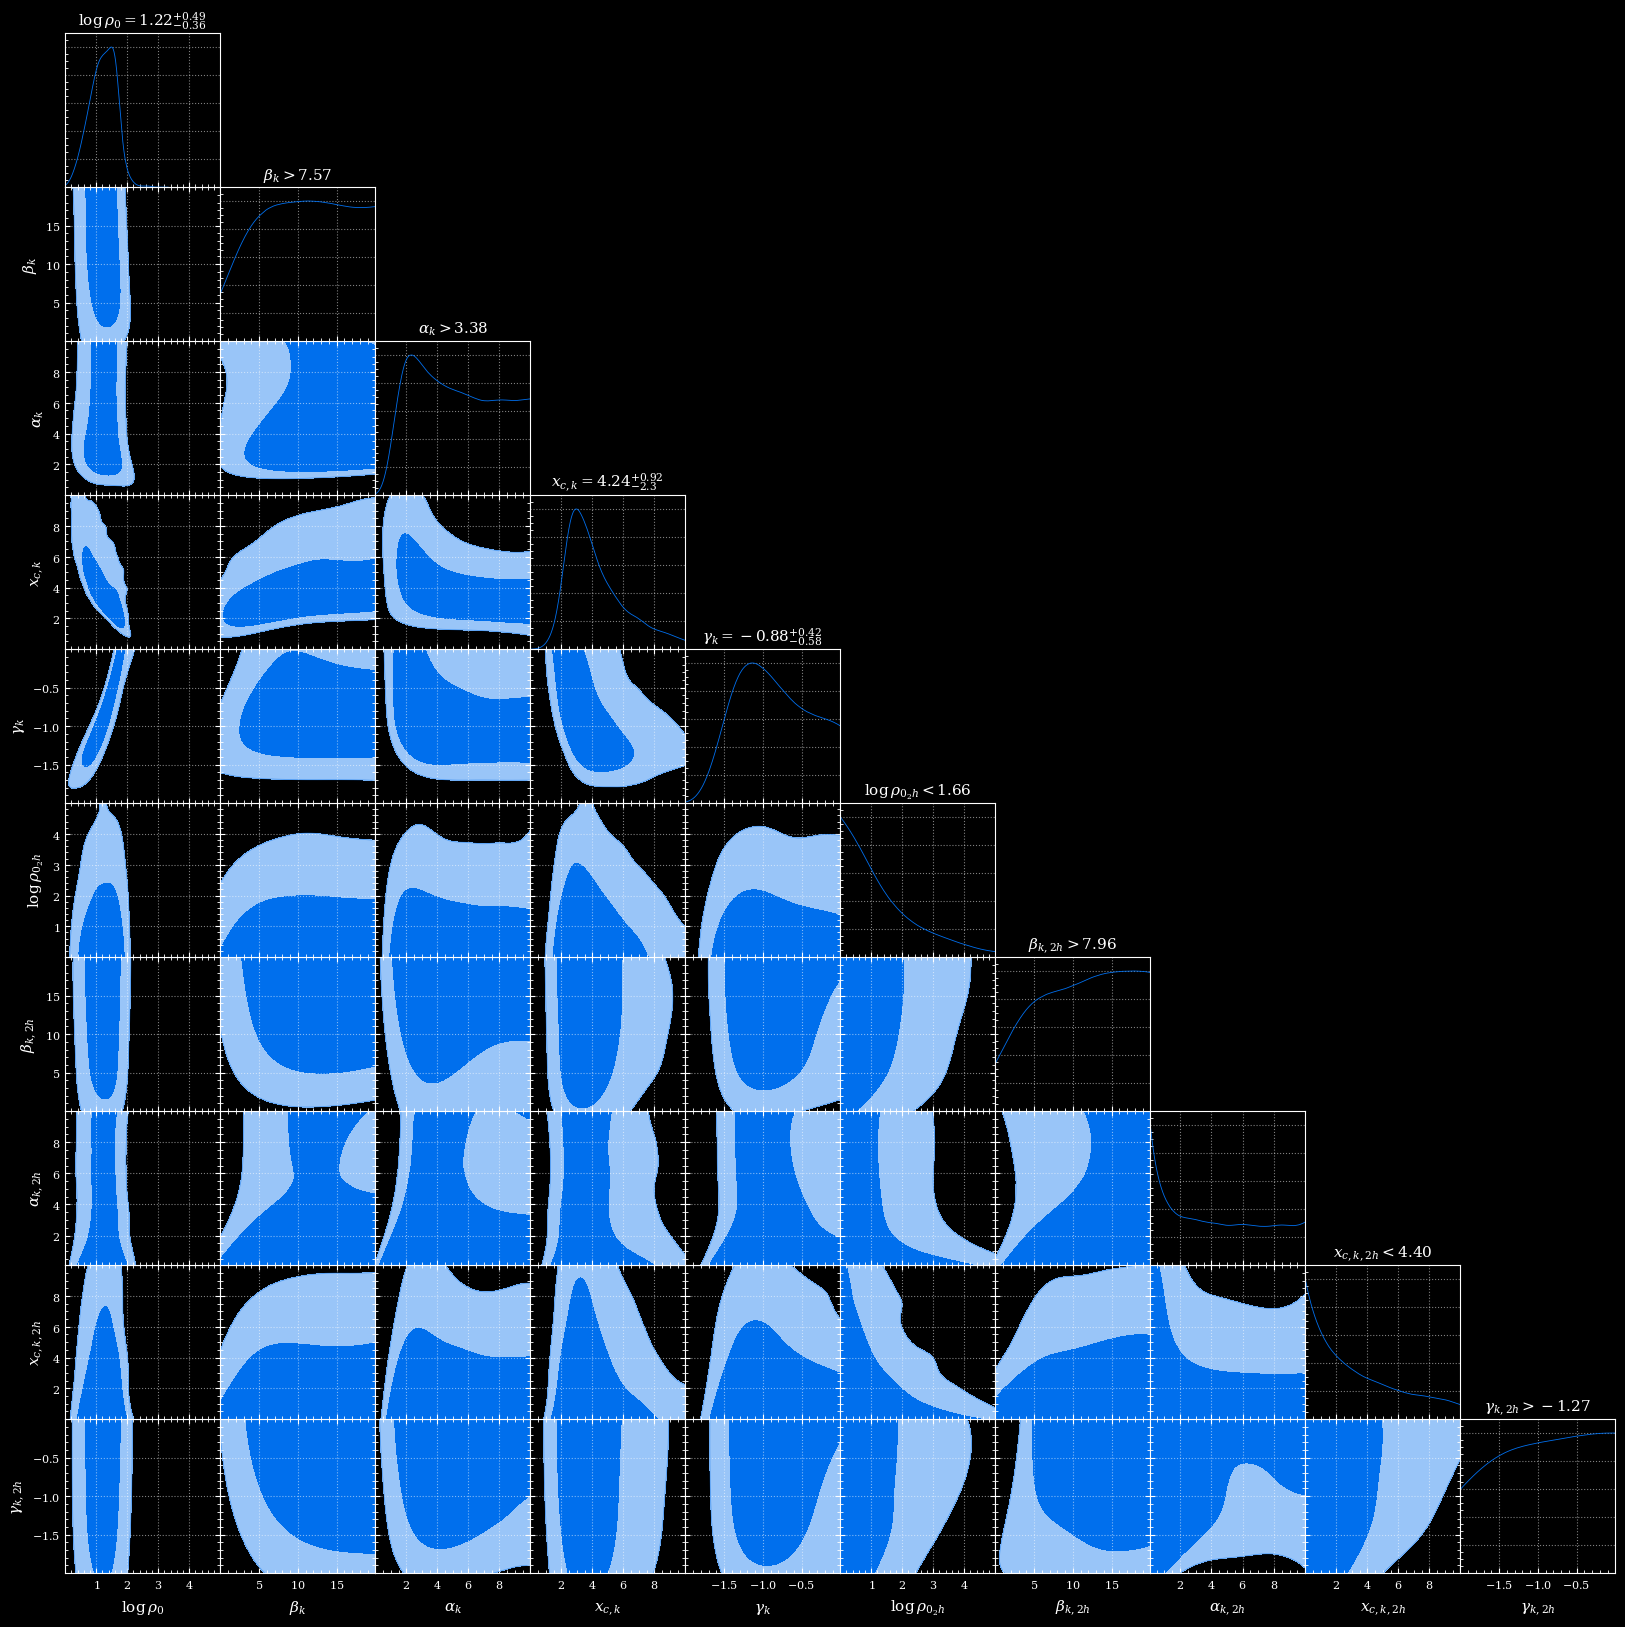

In [8]:
folder,name = os.path.split(os.path.abspath(filename))

pnames = {k: v['prior'] for k, v in yaml_load["params"].items() if 'prior' in v}

gdplot = gdplt.get_subplot_plotter(chain_dir=folder)
gdplot.settings.title_limit_fontsize=14
gdplot.triangle_plot(
    gd_sample, list(pnames.keys()), filled=True, title_fmt='latex', title_limit=1,
    param_limits={k: (v['min'], v['max']) for k, v in pnames.items()})

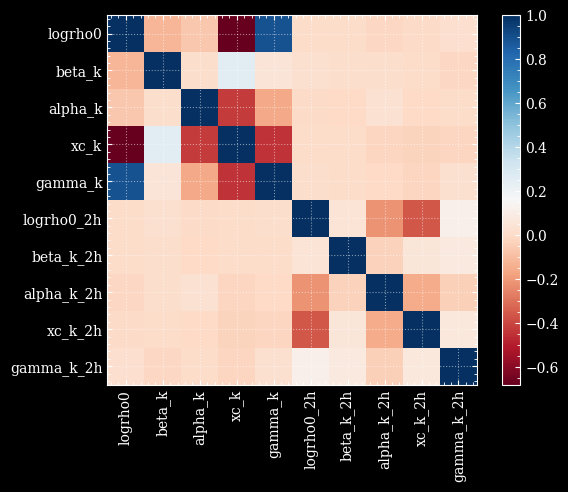

In [75]:
# Full correlation matrix, ordered as gd_sample.paramNames.list()
corr = gd_sample.corr()[:-2, :-2]
param_names = gd_sample.paramNames.list()[:-2]

# Nicely labeled
plt.imshow(corr, cmap='RdBu')
plt.colorbar()
plt.xticks(ticks=np.arange(len(param_names)), labels=param_names, rotation=90)
plt.yticks(ticks=np.arange(len(param_names)), labels=param_names)
plt.show()

In [72]:
param_names = gd_sample.paramNames.list()[:-2]
parschain = dict(zip(param_names, mean))

chainfits = {}
for likeli in likelis.values():
    chainfits[likeli.get_name()] = {
        'chi2overN': -2*likeli.logp(**parschain)/len(likeli.data.x),
        'tot': likeli.model(parschain),
        '1h': likeli.project(likeli.avemeth(likeli.prof1h(parschain))),
        '2h': likeli.project(likeli.avemeth(likeli.prof2h(parschain))),
        'proftot': likeli.avemeth(likeli.prof(parschain)),
        'prof1h': likeli.avemeth(likeli.prof1h(parschain)),
        'prof2h': likeli.avemeth(likeli.prof2h(parschain))
    }

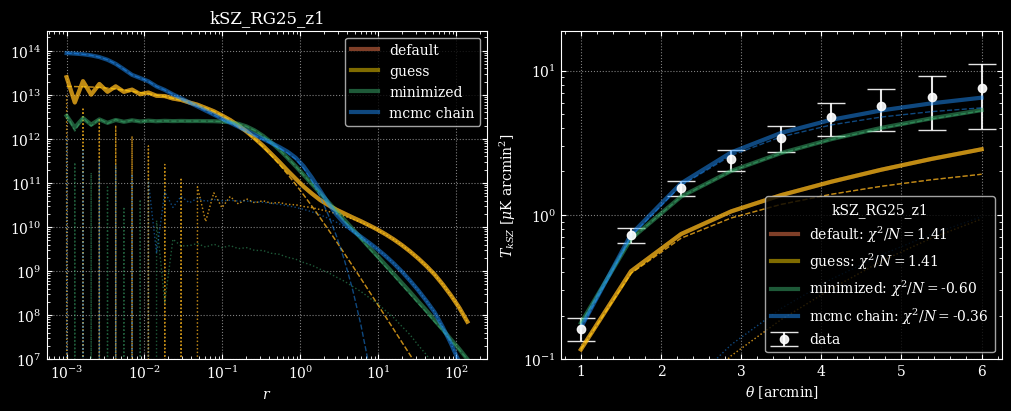

In [74]:
nrows = len(likelis)
fig, axs = plt.subplots(nrows, 2, figsize=(10, 4*nrows), layout='constrained')
if nrows == 1:
    axs = axs[None, :]

versions = [(defaults, 'default', 'coral'), (guesses, 'guess', 'gold'), (minimizerfits, 'minimized', 'mediumseagreen'), (chainfits, 'mcmc chain', 'dodgerblue')]

for (axprof, axdata), likeli in zip(axs, likelis.values()):
    name = likeli.get_name()

    # Left: 1h/2h/total profile (pre-projection) vs r
    for versdict, label, color in versions:
        vers = versdict[name]
        axprof.plot(likeli.r, vers['prof1h'], ls='--', lw=1, c=color, alpha=0.5)
        axprof.plot(likeli.r, vers['prof2h'], ls=':', lw=1, c=color, alpha=0.5)
        axprof.plot(likeli.r, vers['proftot'], lw=3, label=label, c=color, alpha=0.5)
    axprof.set(xscale='log', yscale='log', ylim=(1e7, None), xlabel=r'$r$', title=name)
    axprof.legend()

    # Right: data and projected SZ signal
    axdata.errorbar(likeli.data.x, likeli.data.y, np.diag(likeli.data.cov)**0.5, label='data', c='white', marker='o', capsize=10, ls='None', alpha=0.9)

    for versdict, label, color in versions:
        vers = versdict[name]
        axdata.plot(likeli.data.x, vers['1h'], ls='--', lw=1, c=color, alpha=0.5)
        axdata.plot(likeli.data.x, vers['2h'], ls=':', lw=1, c=color, alpha=0.5)
        axdata.plot(likeli.data.x, vers['tot'], lw=3, label=rf"{label}: $\chi^2/N=${vers['chi2overN']:.2f}", c=color, alpha=0.5)

    axdata.legend(title=name)
    if "kSZ" in name:
        axdata.set(yscale='log', ylim=(1e-1, None), ylabel=r'$T_{kSZ} \ [\mu \text{K} \ \text{arcmin}^2]$', xlabel=r'$\theta$ [arcmin]')
    elif "tSZ" in name:
        axdata.set(ylim=(-0.5e-6, 6e-6), ylabel=r'$y$', xlabel=r'$\theta$ [arcmin]')

plt.show()

# After

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].loglog(model.r, model.aveprof(p0), ls='--', lw=5,label='model guess')
axs[0].loglog(model.r, model.aveprof(parsfit), ls='--', lw=5,label='model quick fit')
axs[0].loglog(model.r, model.aveprof(mean), ls='--', lw=5,label='model fit')
axs[0].set(
    xlabel=r"$r$"+f" [{model.r.unit.to_string(format='latex')}]", ylabel=r"$\rho_\text{gas}$"+f" [{model.aveprof(p0).unit.to_string(format='latex')}]")

axs[1].set(
    xlabel=r"$R$"+f" [{model.meas.R.unit.to_string(format='latex')}]", ylabel=r"$T_\text{kSZ}$"+f" [{model.meas.TkSZ_data.unit.to_string(format='latex')}]",
    yscale='log')
axs[1].errorbar(model.meas.R, model.meas.TkSZ_data, model.meas.TkSZ_err,label='meas data', c='lime', marker='o', capsize=10, ls='None')
axs[1].plot(model.meas.R, model._get_theory(p0), ls='--', lw=5,label='model guess')
axs[1].plot(model.meas.R, model._get_theory(parsfit), ls='--', lw=5,label='model quick fit')
axs[1].plot(model.meas.R, model._get_theory(mean), ls='--', lw=5,label='model fit')

axs[1].legend()
plt.show()

## Plot the results of that 

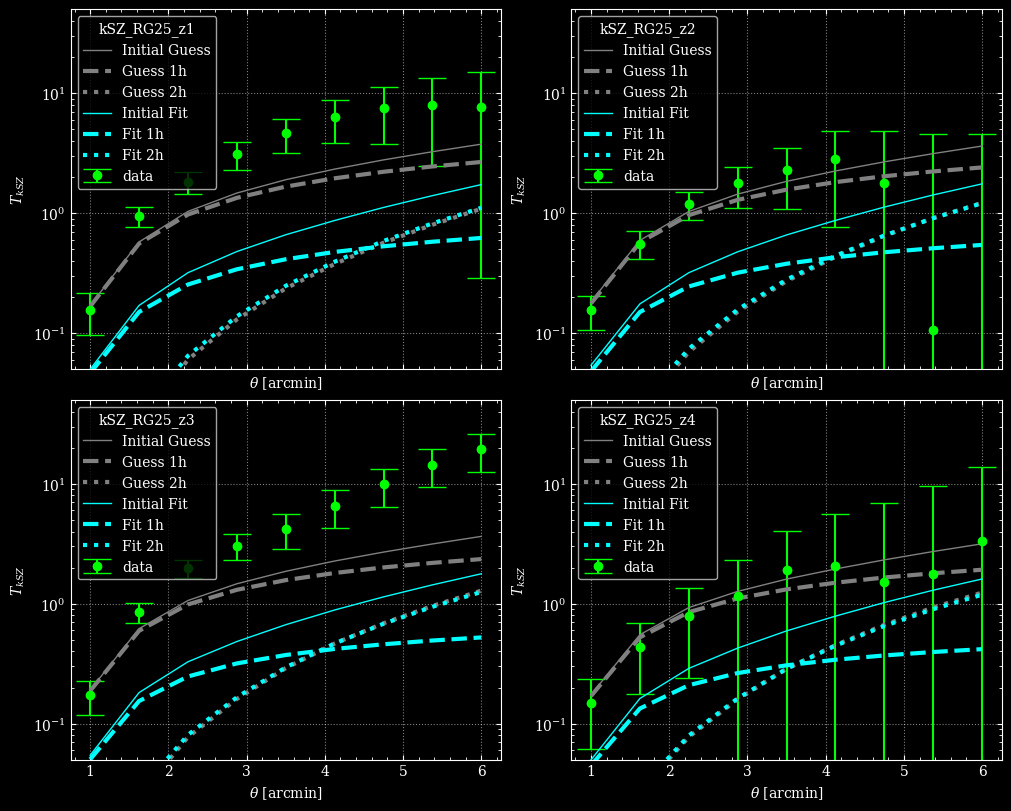

In [16]:
parsfit = {k: minimizer.products()["minimum"][k] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}

fix, axs = plt.subplots(int(np.ceil(len(likelis)/2)), 2, figsize=(10, 4*np.ceil(len(likelis)/2)), layout='constrained', sharex=True)

for ax, likeli in zip(axs.flatten(), likelis.values()):
    ax.errorbar(likeli.data.x, likeli.data.y, np.diag(likeli.data.cov)**0.5, label='data', c='lime', marker='o', capsize=10, ls='None')
    fit = likeli.model(parsfit)
    fit1h = likeli.project(likeli.ave_hod(likeli.prof1h(parsfit)))
    fit2h = likeli.project(likeli.ave_hod(likeli.prof2h(parsfit)))
    
    guess = likeli.model({})
    guess1h = likeli.project(likeli.ave_hod(likeli.prof1h({})))
    guess2h = likeli.project(likeli.ave_hod(likeli.prof2h({})))

    ax.plot(likeli.data.x, guess, lw=1, label='Initial Guess', c='gray')
    ax.plot(likeli.data.x, guess1h, ls='--',lw=3,label='Guess 1h', c='gray')
    ax.plot(likeli.data.x, guess2h, ls=':', lw=3,label='Guess 2h', c='gray')
    
    ax.plot(likeli.data.x, fit, lw=1, label='Initial Fit', c='cyan')
    ax.plot(likeli.data.x, fit1h, ls='--',lw=3,label='Fit 1h', c='cyan')
    ax.plot(likeli.data.x, fit2h, ls=':', lw=3,label='Fit 2h', c='cyan')

    if "kSZ" in likeli.get_name():
        ax.set(yscale='log', ylim=(5e-2, 5e1), ylabel=r'$T_{kSZ}$', xlabel=r'$\theta$ [arcmin]')
    elif "tSZ" in likeli.get_name():
        ax.set(ylim=(-0.5e-6, 6e-6), ylabel=r'$y$', xlabel=r'$\theta$ [arcmin]')
    ax.legend(title=likeli.get_name())

plt.show()

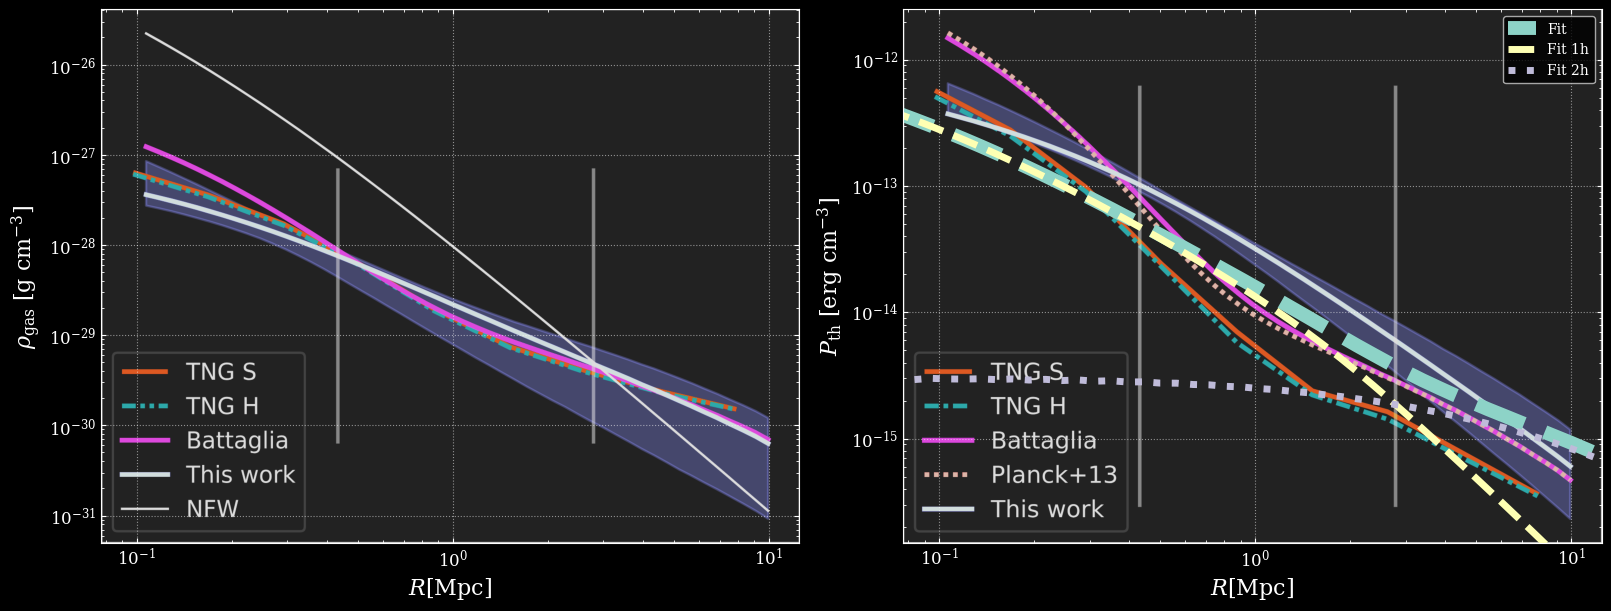

In [37]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, axs = Plots.Amodeo2021().Fig6_row1()

unitsto = u.erg/u.cm**3

for ax, mod in zip(axs, ['asd', likeli]):
    # Plot random z and logM
    if mod=='asd': pass
    else:
        zind, logMind = np.argmin(np.abs(mod.targetdata.z - 0.5)), np.argmin(np.abs(mod.targetdata.logMh - 13.3))
        zmlabel = f'z={mod.targetdata.z[zind]:.2f}, logM={mod.targetdata.logMh[logMind]:.2f}'
        # ax.loglog(mod.r, mod.prof()[:, zind, logMind].cgs, ls='--', lw=10, label=zmlabel)
        # ax.loglog(mod.r, mod.prof2h()[:, zind, logMind].cgs, ls='--', lw=10, label=zmlabel)

        # Plot HOD average profile
        ax.loglog(mod.r, mod.ave_hod(mod.prof(parsfit)).cgs, ls='--', lw=10, label='Fit')
        ax.loglog(mod.r, mod.ave_hod(mod.prof1h(parsfit)).cgs, ls='--', lw=5, label='Fit 1h')
        ax.loglog(mod.r, mod.ave_hod(mod.prof2h(parsfit)).cgs, ls=':', lw=5, label='Fit 2h')
        
        # ax.loglog(mod.r, mod.prof({})[:, zind, logMind].cgs, ls='--', lw=10, label=zmlabel)
        # ax.loglog(mod.r, mod.prof2h()[:, zind, logMind].cgs, ls='--', lw=10, label=zmlabel)

        ax.legend()
plt.show()

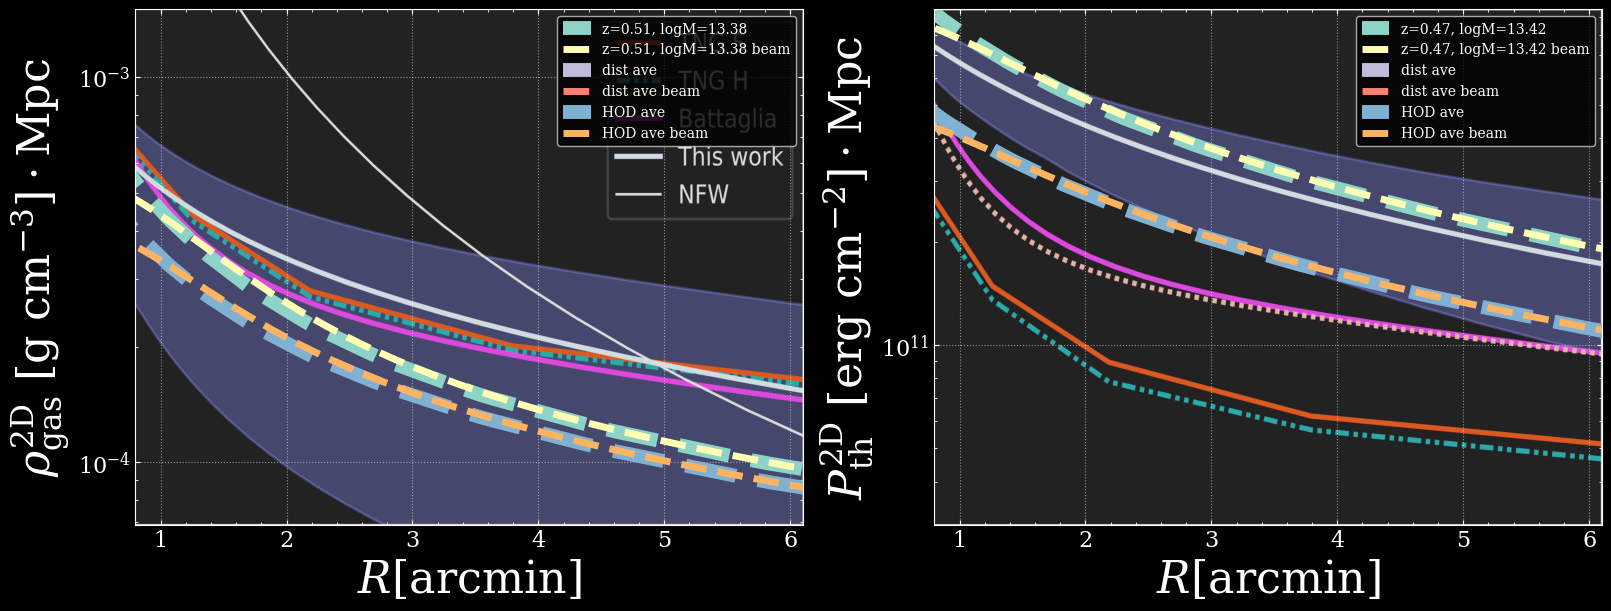

In [124]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, axs = Plots.Amodeo2021().Fig6_row2()

for ax, mod in zip(axs, [kSZ, tSZ]):
    Rs = (mod.proj.rht.r*u.rad).to(u.arcmin)
    
    zind, logMind = np.argmin(np.abs(mod.targetdata.z - mod.targetdata.zMean)), np.argmin(np.abs(mod.targetdata.logMh - mod.targetdata.logMhMean))
    zmlabel = f'z={mod.targetdata.z[zind]:.2f}, logM={mod.targetdata.logMh[logMind]:.2f}'

    prof2D = mod.proj2D(mod.prof()[:, zind, logMind])
    ax.plot(Rs, prof2D.cgs, ls='--', lw=10, label=zmlabel)
    Rbeam, prof2Dbeam = mod.beamconvolve(prof2D)
    ax.plot(Rbeam, prof2Dbeam.cgs, ls='--', lw=5, label=f'{zmlabel} beam')

    profdistave2D = mod.proj2D(mod.ave_smf(mod.prof()))
    ax.plot(Rs, profdistave2D, ls='--', lw=10, label='dist ave')
    Rbeam, prof2Dbeam = mod.beamconvolve(profdistave2D)
    ax.plot(Rbeam, prof2Dbeam, ls='--', lw=5, label=f'dist ave beam')

    profhodave2D = mod.proj2D(mod.ave_hod(mod.prof()))
    ax.plot(Rs, profhodave2D.cgs, ls='--', lw=10, label='HOD ave')
    Rbeam, prof2Dbeam = mod.beamconvolve(profhodave2D)
    ax.plot(Rbeam, prof2Dbeam.cgs, ls='--', lw=5, label=f'HOD ave beam')

    ax.legend()

plt.show()

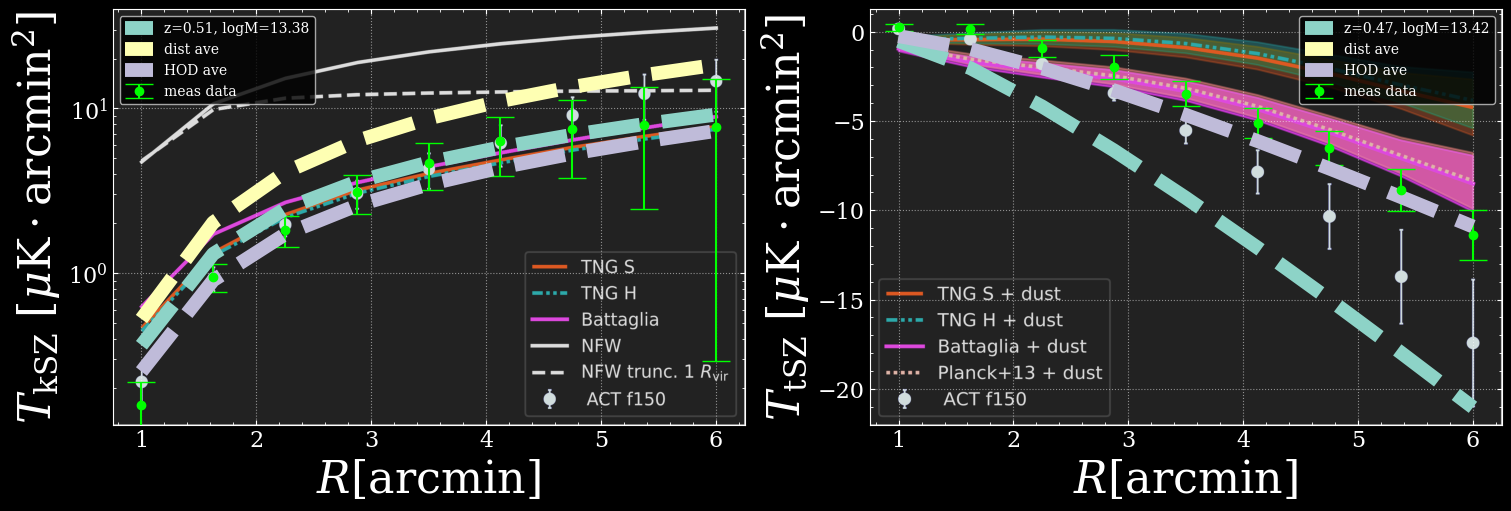

In [ ]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, axs = Plots.Amodeo2021().Fig6_row3()

convs = [1, tSZ.halomodel.y_to_uK(150*u.GHz)]

axs[0].errorbar(kSZ.meas.R, kSZ.meas.TkSZ_data, kSZ.meas.TkSZ_err,label='meas data', c='lime', marker='o', capsize=10, ls='None')
axs[1].errorbar(tSZ.meas.R, tSZ.meas.y_data*convs[1], -tSZ.meas.y_err*convs[1],label='meas data', c='lime', marker='o', capsize=10, ls='None')

for ax, mod, conv in zip(axs, [kSZ, tSZ], convs):
    zind, logMind = np.argmin(np.abs(mod.targetdata.z - mod.targetdata.zMean)), np.argmin(np.abs(mod.targetdata.logMh - mod.targetdata.logMhMean))
    zmlabel = f'z={mod.targetdata.z[zind]:.2f}, logM={mod.targetdata.logMh[logMind]:.2f}'

    modprof = mod.project(mod.prof()[:, zind, logMind])
    ax.plot(mod.meas.R, modprof*conv, ls='--', lw=10,label=zmlabel)

    ax.plot(mod.meas.R, mod.project(mod.ave_smf(mod.prof()))*conv, ls='--', lw=10, label='dist ave')
    ax.plot(mod.meas.R, mod.project(mod.ave_hod(mod.prof()))*conv, ls='--', lw=10, label='HOD ave')
    # ax.plot(mod.meas.R, mod.model({})*conv, ls='--', lw=5,label='model final')
    ax.legend()

plt.show()

In [9]:
from scipy.integrate import simpson as simp

logMs = model.targetdata.logM
Ms = 10**logMs
dndlogM = model.targetdata.dndlogM

print(np.log10(np.trapz(Ms*dndlogM, logMs)/np.trapz(dndlogM, logMs)),
      np.log10(simp(Ms*dndlogM, logMs)/simp(dndlogM, logMs)))
print(np.trapz(logMs*dndlogM, logMs)/np.trapz(dndlogM, logMs),
      simp(logMs*dndlogM, logMs)/simp(dndlogM, logMs))

# Cut off long tails
mcut = (logMs>12.5) & (logMs<14.5)
logMs = logMs[mcut]
Ms = Ms[mcut]
dndlogM = dndlogM[mcut]

print(np.log10(np.trapz(Ms*dndlogM, logMs)/np.trapz(dndlogM, logMs)),
      np.log10(simp(Ms*dndlogM, logMs)/simp(dndlogM, logMs)))
print(np.trapz(logMs*dndlogM, logMs)/np.trapz(dndlogM, logMs),
      simp(logMs*dndlogM, logMs)/simp(dndlogM, logMs))

14.005813403232485 14.005611365227328
13.658483318354147 13.658243002277205
13.796032396485485 13.79614588615424
13.602715886961267 13.602825985801275


In [27]:
logM = model.targetdata.logM
zs = model.targetdata.z

# mcut = (logM>12.5) & (logM<14.5)
# logM = logM[mcut]

Nc, Ns = model.hod.Ncen(logM), model.hod.Nsat(logM)
dndlogm = model.halomodel.dndlogm(zs[:, None], logM)  # calculate halo mass function
# dndlogm[:, (logM<12)] = 0
infac = dndlogm*model.targetdata.dNdz[:, None]  # combined mass/z distributions

ngal = lambda p: np.trapz((Nc(p)+Ns(p))*dndlogm, logM)  # total galaxy number
# Hg = lambda p: (Nc(p) + Ns(p))/ngal(p)[:, None]  # HOD cross-spectra function
Hg = lambda p: (Nc(p)[None, None, :] + Ns(p)[None, None, :])/ngal(p)[:, None]  # HOD cross-spectra function
Hg_norm = lambda p: Hg(p)/np.trapz(np.trapz(Hg(p)*infac, logM), zs)  # normalized galaxy distribution
Hg_norm({}).shape
intfac0 = Hg_norm({})*infac  # combine default HOD galaxy dist into integrand factor
intfac = lambda p: Hg_norm(p)*infac if p!={} else intfac0  # recalculate integrand factor if HOD galaxy dist is being fit

print(np.log10(np.trapz(np.trapz(10**logM*intfac0, logM), zs)))  # take mass/redshift average
print(np.trapz(np.trapz(logM*intfac0, logM), zs))  # take mass/redshift average

[13.39401814]
[13.00696436]


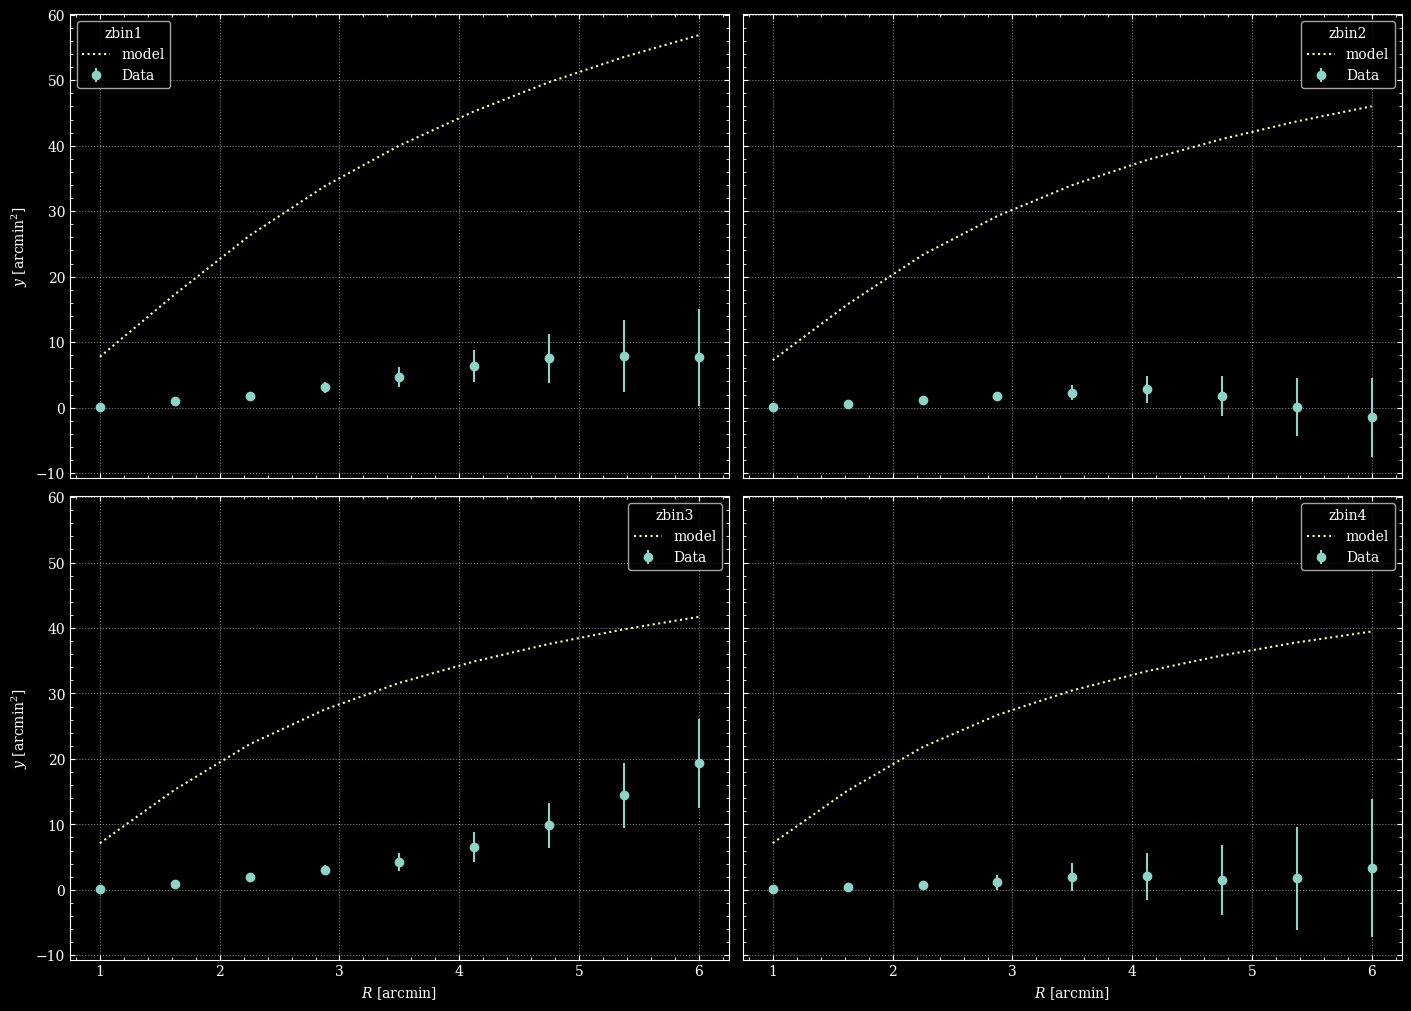

In [133]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10), layout='constrained', sharex=True, sharey=True)
axs=axs.flatten()
for ax in [axs[0], axs[2]]: ax.set(ylabel=r'$y$ [arcmin$^2$]')
for ax in [axs[2], axs[3]]: ax.set(xlabel=r'$R$ [arcmin]')
for ax, likeli in zip(axs, yamlinfo['likelihood'].keys()):
    print
    ax.errorbar(model[likeli].meas.R, model[likeli].meas.TkSZ_data, np.diag(model[likeli].meas.TkSZ_cov)**0.5, marker='o', ls='', label='Data')
    ax.plot(model[likeli].meas.R, model[likeli]._get_theory(refparams), label='model', ls=':')
    ax.legend(title=likeli)
plt.show()

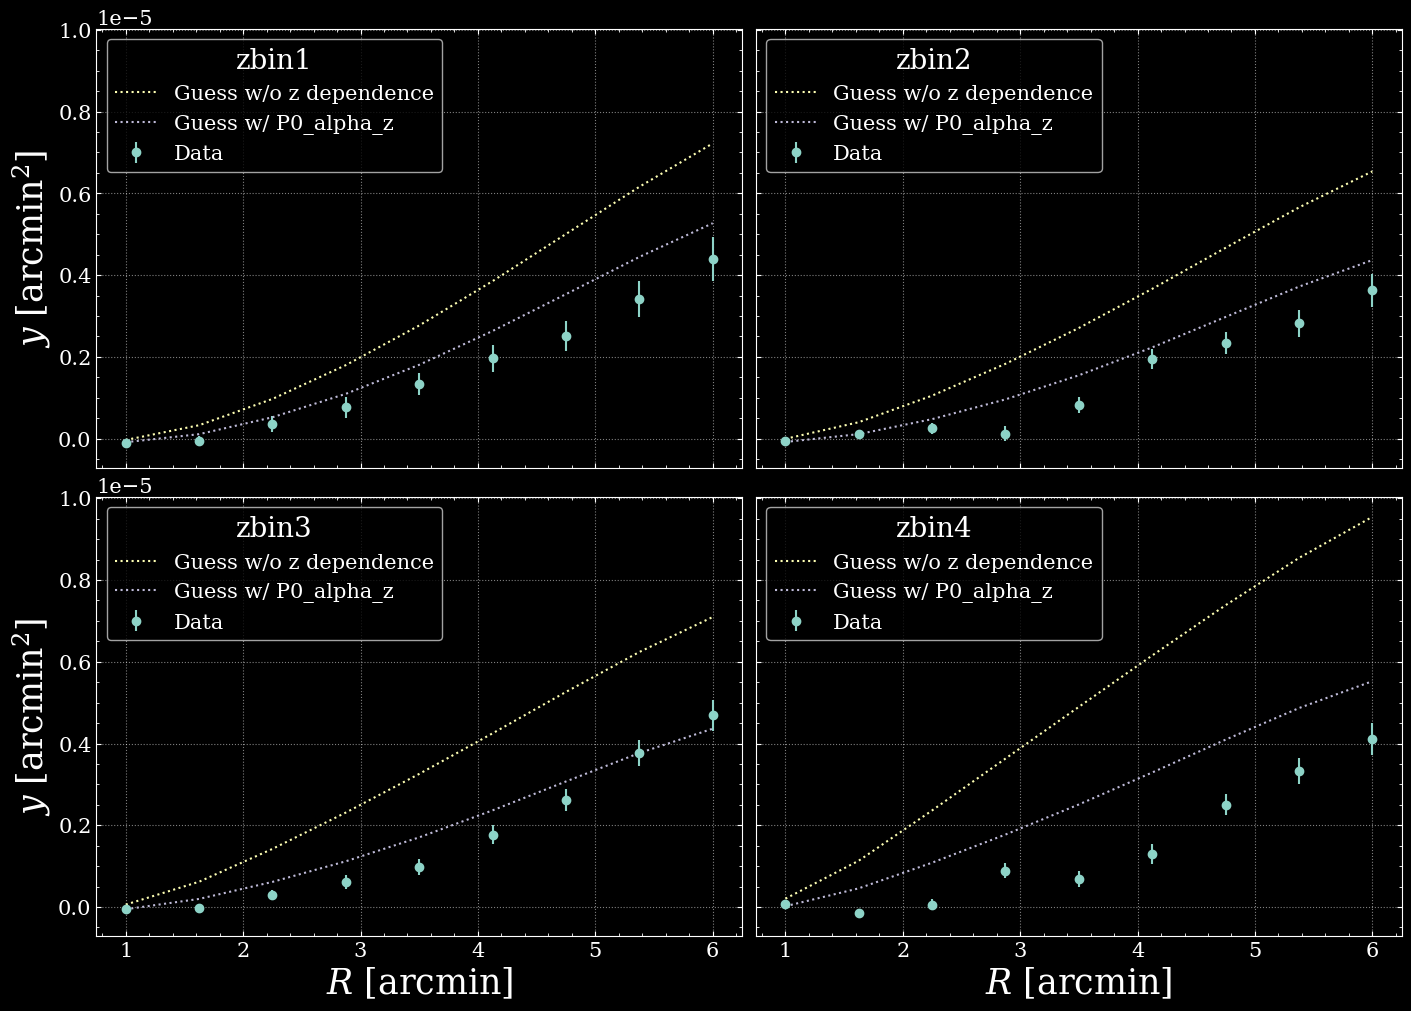

In [ ]:
pars01 = refparams | {'P0_alphaz':-0.8}
pars00= refparams | {'P0_alphaz':0}

fig, axs = plt.subplots(2, 2, figsize=(14, 10), layout='constrained', sharex=True, sharey=True)
axs=axs.flatten()
for ax in [axs[0], axs[2]]: ax.set(ylabel=r'$y$ [arcmin$^2$]')
for ax in [axs[2], axs[3]]: ax.set(xlabel=r'$R$ [arcmin]')
for ax, likeli in zip(axs, yamlinfo['likelihood'].keys()):
    print
    ax.errorbar(model[likeli].meas.R, model[likeli].meas.y_data, np.diag(model[likeli].meas.y_cov)**0.5, marker='o', ls='', label='Data')
    ax.plot(model[likeli].meas.R, model[likeli]._get_theory(pars00), label='Guess w/o z dependence', ls=':')
    ax.plot(model[likeli].meas.R, model[likeli]._get_theory(pars01), label='Guess w/ P0_alpha_z', ls=':')
    ax.legend(title=likeli)
plt.show()

In [ ]:
SOLikelihoods.YAML_FILE = f"{CAPPIBARAS_PATH}/chains/runchainsRiedGuachalla.yaml"

# Run a quick minimizer but change the output file so it doesn't overwrite the real one
yamlinfo_min = cobaya.yaml.yaml_load_file(SOLikelihoods.YAML_FILE).copy()
yamlinfo_min["output"] = yamlinfo_min["output"] + "_minimizer"
updated_info_minimizer, minimizer = cobaya.run(yamlinfo_min, minimize=True, force=True)
# minimum = minimizer.products()["minimum"]
# parsfit = {k: minimum[k] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}

# fig, axs = plt.subplots(2, 2, figsize=(14, 10), layout='constrained', sharex=True, sharey=True)
# axs=axs.flatten()
# for ax in [axs[0], axs[2]]: ax.set(ylabel=r'$y$ [arcmin$^2$]')
# for ax in [axs[2], axs[3]]: ax.set(xlabel=r'$R$ [arcmin]')
# for ax, likeli in zip(axs, yamlinfo['likelihood'].keys()):
#     ax.errorbar(model[likeli].meas.R, model[likeli].meas.y_data, np.diag(model[likeli].meas.y_cov)**0.5, marker='o', ls='', label='Data')
#     ax.plot(model[likeli].meas.R, model[likeli]._get_theory(pars0), label='Guess', ls=':')
#     ax.plot(model[likeli].meas.R, model[likeli]._get_theory(dict(minimum.MAP())), label='Minimizer')
#     ax.legend(title=likeli)
# plt.show()

# Pre-fit

In [ ]:
# Reload modules to updates
importlib.reload(SOLikelihoods)

SOLikelihoods.YAML_FILE = f"{CAPPIBARAS_PATH}/chains/runchainsRiedGuachalla.yaml"
SOLikelihoods.VERBOSE = False

# Run a quick minimizer but change the output file so it doesn't overwrite the real one
yamlinfo_min = cobaya.yaml.yaml_load_file(SOLikelihoods.YAML_FILE).copy()
yamlinfo_min["output"] = yamlinfo_min["output"] + "_minimizer"
updated_info_minimizer, minimizer = cobaya.run(yamlinfo_min, minimize=True, force=True)

parsfit = {k: minimizer.products()["minimum"][k] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}
p0 = {k: v['ref'] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}
parslabel = [v['latex'] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v]

likelis = list(minimizer.model.likelihood.keys())

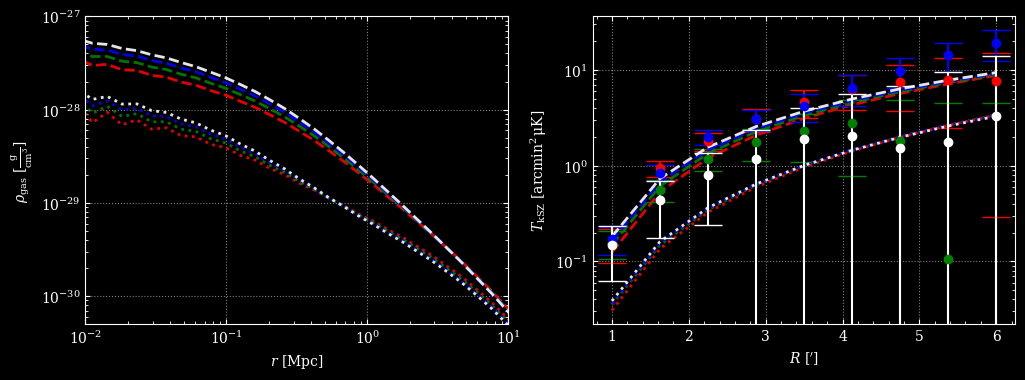

In [ ]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].set(
    xlabel=r"$r$"+f" [{model.r.unit.to_string(format='latex')}]", ylabel=r"$\rho_\text{gas}$"+f" [{model.aveprof(p0).to(u.g/u.cm**3).unit.to_string(format='latex')}]",
    xlim=(1e-2, 1e1), ylim=(5e-31,1e-27))

axs[1].set(
    xlabel=r"$R$"+f" [{model.meas.R.unit.to_string(format='latex')}]", ylabel=r"$T_\text{kSZ}$"+f" [{model.meas.TkSZ_data.unit.to_string(format='latex')}]",
    yscale='log')

colors = ['r', 'g', 'b', 'w']

for likeli, c in zip(likelis, colors):

    model = minimizer.model.likelihood[likeli]

    axs[0].loglog(model.r, model.aveprof(p0).to(u.g/u.cm**3), ls=':', lw=2,c=c, alpha=0.9,label=f'guess {likeli}')
    axs[0].loglog(model.r, model.aveprof(parsfit).to(u.g/u.cm**3), ls='--', lw=2,alpha=0.9,c=c,label=f'fit {likeli}')

    axs[1].errorbar(model.meas.R, model.meas.TkSZ_data, model.meas.TkSZ_err,c=c,label=f'data {likeli}', marker='o', capsize=10, ls='None')
    axs[1].plot(model.meas.R, model._get_theory(p0), ls=':', lw=2,c=c,alpha=0.9,label=f'guess {likeli}')
    axs[1].plot(model.meas.R, model._get_theory(parsfit), ls='--', lw=2,c=c,alpha=0.9,label=f'fit {likeli}')

# axs[0].legend(fontsize); axs[1].legend()
plt.show()